# Module 09 — Advanced Preprocessing & Feature Engineering
## Outlier Detection · Feature Transformation · Domain Features · Pipeline
---
> এই module-এ Module 07-এর core preprocessing-এর উপর দাঁড়িয়ে আরো advanced techniques শেখা হবে।  
> শুধু missing values fill আর encoding নয় — এখন outlier সামলানো, feature বানানো, pipeline তৈরি করা।

**Dataset:** Heart Failure Prediction (`heart.csv` — same folder-এ রাখো)

| Section | Topic |
|---|---|
| 9.1 | Module পরিচয় ও recap |
| 9.2–9.3 | Outlier Detection ও Handling (IQR, Z-score) |
| 9.4–9.6 | Feature Transformation: Polynomial, Binning, Domain Features |
| 9.7 | Complete Preprocessing Pipeline |
| 9.8 | Sanity Check — Simple Model দিয়ে test |


---
## 9.1 Introduction — Advanced Preprocessing কেন দরকার?

### Module 07-এ যা শিখেছিলাম (Recap)
```
Missing values  -> fillna(median/mode), drop
Label Encoding  -> binary: 0/1
OneHot Encoding -> nominal: get_dummies()
Scaling         -> StandardScaler, MinMaxScaler
```

### এই module-এ যা শিখব (নতুন)
```
Outlier Detection  -> IQR method, Z-score
Outlier Handling   -> remove, cap (winsorize), log transform
Polynomial Features -> Age^2, Age*MaxHR -- non-linear patterns
Binning            -> continuous -> categorical (Young/Middle/Old)
Domain Features    -> BP_Risk, Oldpeak_Risk -- expert knowledge
Full Pipeline      -> ColumnTransformer + Pipeline + Model
Sanity Check       -> pipeline error নেই? leakage নেই?
```

### কেন এগুলো দরকার?

| Problem | Effect | Solution |
|---|---|---|
| Outlier আছে | Model distort হয় | IQR removal / capping |
| Linear relationship নেই | Linear model fail করে | Polynomial features |
| Continuous variable complex | Interpretation কঠিন | Binning |
| Domain knowledge আছে | Raw feature weak | Domain-driven feature |
| Manual preprocessing ভুলের ঝুঁকি | Data leakage | sklearn Pipeline |

### 🎯 Interview Topics
- Advanced preprocessing কি সবসময় দরকার? → না, simple dataset-এ overkill, complex real data-তে necessary
- Feature engineering vs Feature selection পার্থক্য? → Engineering=নতুন feature তৈরি, Selection=কোনটা রাখব বেছে নেওয়া
- Pipeline কেন use করব manually করার বদলে? → Data leakage prevent, reproducible, deployable


In [20]:
# Now we do setup -- import all libraries needed for this module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler,
    OneHotEncoder, PolynomialFeatures
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

plt.style.use("default")
sns.set(font_scale=1.1)
print("All imports done!")

All imports done!


> 📝 **এই code-এ কী হচ্ছে:** সব দরকারি library একসাথে import করা হয়েছে। এই module-এ sklearn-এর preprocessing, pipeline, এবং metrics — তিনটি sub-package একসাথে ব্যবহার হবে।

In [21]:
# Now we load heart.csv and do quick preprocessing (from Module 07)
# This sets up df_heart and df_heart_encoded for the rest of the module

df_heart = pd.read_csv("Heart-Dataset.csv")
print("Shape:", df_heart.shape)
print(df_heart.head(3))

# Here we do Label Encoding for binary columns
le = LabelEncoder()
df_heart["Sex"]            = le.fit_transform(df_heart["Sex"])
df_heart["ExerciseAngina"] = le.fit_transform(df_heart["ExerciseAngina"])

# Here we do OneHot Encoding for nominal columns
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df_heart_encoded = pd.get_dummies(df_heart, columns=cat_cols, dtype=int)

print("\nEncoded shape:", df_heart_encoded.shape)
print("Columns:", df_heart_encoded.columns.tolist())

Shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  

Encoded shape: (918, 19)
Columns: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


> 📝 **এই code-এ কী হচ্ছে:** Module 07-এর preprocessing steps এখানে একসাথে করে `df_heart_encoded` তৈরি করা হয়েছে। এই DataFrame-টাই এই পুরো module-এ ব্যবহার হবে।

---
## 9.2–9.3 Outlier Detection ও Handling

### Real-life Analogy (Module Notebook থেকে)
> একজন student 100-এর মধ্যে 500 পেয়েছে।  
> বাকিরা সবাই 60-90 পেয়েছে।  
> এই 500 সহ average বের করলে class average অর্থহীন হয়ে যাবে।  
> ML-এও extreme values model distort করে।

### Outlier কী?
> Outlier = data-র normal range থেকে অনেক দূরে থাকা value।  
> দুটো কারণে হতে পারে: **data entry error** বা **genuine extreme case**।

### IQR Method (সবচেয়ে Common)
```
Q1 = 25th percentile
Q3 = 75th percentile
IQR = Q3 - Q1

Lower bound = Q1 - 1.5 * IQR
Upper bound = Q3 + 1.5 * IQR

এই range-এর বাইরে = Outlier
```

### Z-Score Method
```
z = (x - mean) / std
|z| > 3  ->  Outlier (মানে mean থেকে 3 standard deviation দূরে)
```

### Outlier Handle করার তিনটি পদ্ধতি

| পদ্ধতি | কী করে | কখন |
|---|---|---|
| **Remove** | Outlier row delete করে | Data entry error নিশ্চিত হলে |
| **Cap (Winsorize)** | Bound-এ clip করে | Genuine extreme but keep them |
| **Log Transform** | log(x+1) করে | Right-skewed distribution-এ |

### 🎯 Interview Topics
- IQR vs Z-score কখন কোনটা? → IQR non-parametric (distribution assume করে না), Z-score Normal distribution assume করে
- Winsorization কী? → Outlier remove না করে bound-এ clamping — sample size maintain হয়
- Log transform কখন? → Right-skewed data-তে, সব value positive হতে হবে (`log(x+1)` negative handle করে)
- Outlier সবসময় remove করতে হবে? → না! Medical data-তে extreme value real হতে পারে — domain knowledge দিয়ে সিদ্ধান্ত


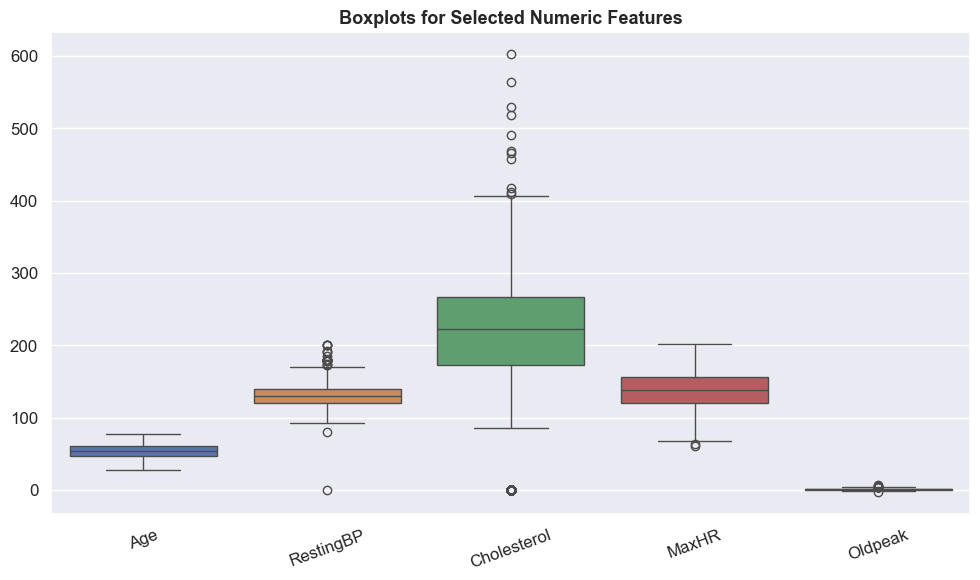

READING THE BOXPLOT:
  Box = Q1 to Q3 (middle 50% data)
  Orange line = Median
  Dots outside whiskers = OUTLIERS

Observations:
  Cholesterol: many dots above -- possibly some 0 values too
  RestingBP:   a few high outliers visible
  Oldpeak:     right-skewed, outliers on high side


In [22]:
# Now we visualize numeric columns with boxplots (module notebook cell 22)

numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_heart_encoded[numeric_cols])
plt.title("Boxplots for Selected Numeric Features", fontsize=13, fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("READING THE BOXPLOT:")
print("  Box = Q1 to Q3 (middle 50% data)")
print("  Orange line = Median")
print("  Dots outside whiskers = OUTLIERS")
print()
print("Observations:")
print("  Cholesterol: many dots above -- possibly some 0 values too")
print("  RestingBP:   a few high outliers visible")
print("  Oldpeak:     right-skewed, outliers on high side")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact boxplot code। Numeric columns-এর boxplot একসাথে দেখা হয়েছে — কোন column-এ কতটা outlier সেটা এক নজরে বোঝা যায়। Cholesterol-এ সবচেয়ে বেশি outlier দেখা যাবে (0 values সহ)।

In [23]:
# Now we detect outliers using IQR method (module notebook cell 23)
# Using Cholesterol as the example column

col = "Cholesterol"

Q1  = df_heart_encoded[col].quantile(0.25)
Q3  = df_heart_encoded[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_heart_encoded[
    (df_heart_encoded[col] < lower) | (df_heart_encoded[col] > upper)
]

print(f"IQR Analysis for '{col}':")
print(f"  Q1 (25th percentile): {Q1:.1f}")
print(f"  Q3 (75th percentile): {Q3:.1f}")
print(f"  IQR = Q3 - Q1:        {IQR:.1f}")
print(f"  Lower bound:          {lower:.1f}")
print(f"  Upper bound:          {upper:.1f}")
print()
print(f"Number of detected outliers in {col}: {len(outliers)}")
print()
print("Sample outlier rows:")
print(outliers[[col, "HeartDisease"]].head(8))

IQR Analysis for 'Cholesterol':
  Q1 (25th percentile): 173.2
  Q3 (75th percentile): 267.0
  IQR = Q3 - Q1:        93.8
  Lower bound:          32.6
  Upper bound:          407.6

Number of detected outliers in Cholesterol: 183

Sample outlier rows:
     Cholesterol  HeartDisease
28           468             0
30           518             1
69           412             0
76           529             1
103          466             1
149          603             1
250          491             1
293            0             1


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact IQR outlier detection code। Q1, Q3, IQR calculate করে lower ও upper bound বের করা হয়েছে। এই bound-এর বাইরের সব row outlier। Cholesterol = 0 এই outlier-দের মধ্যে পড়বে — biologically impossible value।

In [24]:
# Now we handle outliers in 3 different ways (module notebook cell 24)

print(f"Original dataset size: {len(df_heart_encoded)}")
print()

# Method 1: REMOVE outliers -- delete those rows
df_no_outliers = df_heart_encoded[
    (df_heart_encoded[col] >= lower) & (df_heart_encoded[col] <= upper)
].copy()
print(f"After REMOVAL: {len(df_no_outliers)} rows remain "
      f"({len(df_heart_encoded) - len(df_no_outliers)} removed)")

# Method 2: CAP outliers (Winsorization) -- clip to bounds
df_capped = df_heart_encoded.copy()
df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
print(f"After CAPPING: {len(df_capped)} rows (no rows removed)")
print(f"  {col} min: {df_capped[col].min():.1f}, max: {df_capped[col].max():.1f}")

# Method 3: LOG TRANSFORM -- reduce skewness
df_log = df_heart_encoded.copy()
df_log[col + "_log"] = np.log(df_log[col] + 1)  # +1 to handle 0 values
print(f"After LOG TRANSFORM: new column '{col}_log' added")
print(f"  Original range:  [{df_heart_encoded[col].min():.1f}, {df_heart_encoded[col].max():.1f}]")
print(f"  Log range:       [{df_log[col+'_log'].min():.3f}, {df_log[col+'_log'].max():.3f}]")

Original dataset size: 918

After REMOVAL: 735 rows remain (183 removed)
After CAPPING: 918 rows (no rows removed)
  Cholesterol min: 32.6, max: 407.6
After LOG TRANSFORM: new column 'Cholesterol_log' added
  Original range:  [0.0, 603.0]
  Log range:       [0.000, 6.404]


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর three outlier handling methods। Method 1 (Remove): outlier rows delete করে — sample size কমে। Method 2 (Cap/Winsorize): bound-এ clip করে — rows কমে না, কিন্তু extreme values flatten হয়। Method 3 (Log): `log(x+1)` করে range compress করে — 0 handle করতে +1 দেওয়া হয়। কোনটা বেছে নেবো সেটা domain knowledge ও dataset-এর nature অনুযায়ী।

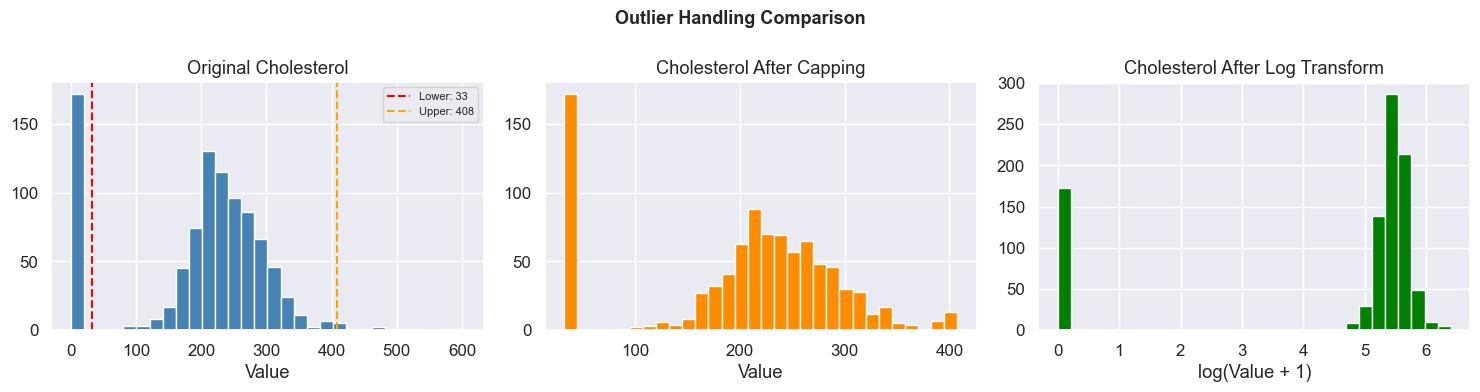

In [25]:
# Now we visualize the effect of each method

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original (with outliers)
axes[0].hist(df_heart_encoded[col], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title(f"Original {col}")
axes[0].set_xlabel("Value")
axes[0].axvline(lower, color="red",    linestyle="--", label=f"Lower: {lower:.0f}")
axes[0].axvline(upper, color="orange", linestyle="--", label=f"Upper: {upper:.0f}")
axes[0].legend(fontsize=8)

# After capping
axes[1].hist(df_capped[col], bins=30, color="darkorange", edgecolor="white")
axes[1].set_title(f"{col} After Capping")
axes[1].set_xlabel("Value")

# After log transform
axes[2].hist(df_log[col + "_log"], bins=30, color="green", edgecolor="white")
axes[2].set_title(f"{col} After Log Transform")
axes[2].set_xlabel("log(Value + 1)")

plt.suptitle("Outlier Handling Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** তিনটি method-এর visual comparison। Original-এ red/orange dashed line দিয়ে outlier bounds দেখানো হয়েছে। Capping-এ extreme values bound-এ pile up করে। Log transform-এ distribution আরো compact এবং bell curve-এর মতো হয়।

In [26]:
# BONUS: Z-score method for outlier detection

from scipy import stats

print("Z-score Outlier Detection:")
print()

for c in ["Cholesterol", "RestingBP", "Oldpeak"]:
    z_scores = np.abs(stats.zscore(df_heart_encoded[c]))
    z_outliers = (z_scores > 3).sum()
    print(f"  {c:15s}: {z_outliers} outliers (|z| > 3)")

print()
print("Comparison: IQR vs Z-score for Cholesterol:")
z_chol = np.abs(stats.zscore(df_heart_encoded["Cholesterol"]))
z_out_count   = (z_chol > 3).sum()
iqr_out_count = len(outliers)
print(f"  IQR method:     {iqr_out_count} outliers")
print(f"  Z-score method: {z_out_count} outliers")
print()
print("Note: IQR is non-parametric (no distribution assumption)")
print("      Z-score assumes roughly Normal distribution")

Z-score Outlier Detection:

  Cholesterol    : 3 outliers (|z| > 3)
  RestingBP      : 8 outliers (|z| > 3)
  Oldpeak        : 7 outliers (|z| > 3)

Comparison: IQR vs Z-score for Cholesterol:
  IQR method:     183 outliers
  Z-score method: 3 outliers

Note: IQR is non-parametric (no distribution assumption)
      Z-score assumes roughly Normal distribution


> 📝 **এই code-এ কী হচ্ছে:** Z-score method দিয়ে outlier detection — IQR-এর alternative। Z-score = (value - mean) / std। |z| > 3 মানে mean থেকে 3 standard deviation দূরে — outlier। IQR vs Z-score comparison দেখানো হয়েছে — IQR সাধারণত বেশি outlier detect করে কারণ distribution assume করে না।

---
## 9.4–9.6 Feature Transformation ও Domain-Driven Features

### Real-life Analogy (Module Notebook থেকে)
> বিদ্যুৎ বিল: 2400, 2600, 2800, 9000, 2700 টাকা।  
> Raw number হিসেবে দেখলে pattern বোঝা কঠিন।  
> LOW/MEDIUM/HIGH category-তে রাখলে behavior বোঝা সহজ।

### তিনটি Feature Engineering Technique

#### 1. Polynomial Features
> Non-linear relationship capture করতে।  
> `Age^2`, `Age × MaxHR` — model-এ curved pattern শিখতে পারে।

```python
PolynomialFeatures(degree=2)  # original + squared + interaction
# Age, MaxHR -> Age, MaxHR, Age^2, Age*MaxHR, MaxHR^2
```

#### 2. Binning (Discretization)
> Continuous variable → Categorical groups।  
> Age: 0-30=Young, 31-50=Middle, 51-70=MiddleOld, 71+=Old

```python
pd.cut(df['Age'], bins=[0,30,50,70,100], labels=['Young','Middle','MiddleOld','Old'])
```

#### 3. Domain-Driven Features
> Medical knowledge ব্যবহার করে meaningful feature তৈরি।  
> RestingBP < 120 = Normal, 120-140 = Elevated, > 140 = High।

### 🎯 Interview Topics
- Polynomial features কেন? → Linear model শুধু straight line শেখে, polynomial দিলে curve শিখতে পারে
- Degree বাড়ালে কী হয়? → Features exponentially বাড়ে (curse of dimensionality), overfitting ঝুঁকি
- Binning কখন useful? → Non-monotonic relationship-এ, interpretability দরকার হলে
- Domain feature কেন best? → Data-র real meaning বোঝে, raw feature-এর চেয়ে predictive
- Feature explosion সমস্যা কী? → অনেক features → slow training, overfitting → feature selection দরকার


In [27]:
# Now we create polynomial features (module notebook cell 26)

from sklearn.preprocessing import PolynomialFeatures

# Use Age and MaxHR for polynomial feature demo
poly_cols = ["Age", "MaxHR"]
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features      = poly.fit_transform(df_heart_encoded[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)

print("Polynomial feature names (degree=2):")
print(poly_feature_names)
print()
print(f"Original shape: {df_heart_encoded[poly_cols].shape}")
print(f"After polynomial: {poly_features.shape}")
print()
print("Sample values (first 3 rows):")
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)
print(poly_df.head(3).round(2))
print()
print("Explanation of each feature:")
print("  Age      -> original Age")
print("  MaxHR    -> original MaxHR")
print("  Age^2    -> Age squared (captures non-linear effect)")
print("  Age MaxHR -> Age x MaxHR interaction (combined effect)")
print("  MaxHR^2  -> MaxHR squared")

Polynomial feature names (degree=2):
['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']

Original shape: (918, 2)
After polynomial: (918, 5)

Sample values (first 3 rows):
    Age  MaxHR   Age^2  Age MaxHR  MaxHR^2
0  40.0  172.0  1600.0     6880.0  29584.0
1  49.0  156.0  2401.0     7644.0  24336.0
2  37.0   98.0  1369.0     3626.0   9604.0

Explanation of each feature:
  Age      -> original Age
  MaxHR    -> original MaxHR
  Age^2    -> Age squared (captures non-linear effect)
  Age MaxHR -> Age x MaxHR interaction (combined effect)
  MaxHR^2  -> MaxHR squared


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact polynomial features code। `PolynomialFeatures(degree=2)` দিলে 2টি feature থেকে 5টি feature তৈরি হয়: original + squared + interaction। `include_bias=False` দিলে constant column (1) বাদ যায়। Age^2 capture করে: বয়স বাড়লে heart disease risk non-linearly বাড়তে পারে।

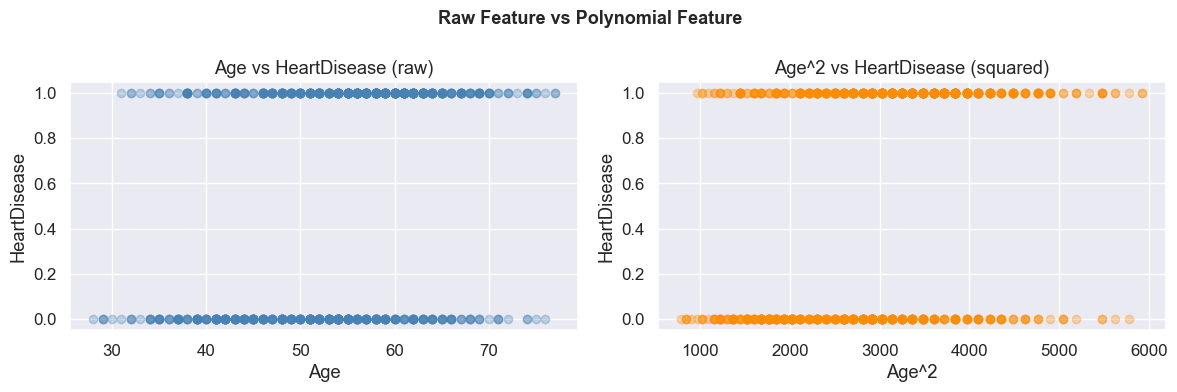

Key point: Polynomial features let linear models learn non-linear patterns!


In [28]:
# Now we visualize why polynomial features help

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: Age vs HeartDisease (linear relationship hard to see)
axes[0].scatter(df_heart_encoded["Age"],
                df_heart_encoded["HeartDisease"],
                alpha=0.3, color="steelblue")
axes[0].set_title("Age vs HeartDisease (raw)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("HeartDisease")

# Scatter: Age^2 vs HeartDisease (clearer trend possible)
axes[1].scatter(df_heart_encoded["Age"]**2,
                df_heart_encoded["HeartDisease"],
                alpha=0.3, color="darkorange")
axes[1].set_title("Age^2 vs HeartDisease (squared)")
axes[1].set_xlabel("Age^2")
axes[1].set_ylabel("HeartDisease")

plt.suptitle("Raw Feature vs Polynomial Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Key point: Polynomial features let linear models learn non-linear patterns!")

> 📝 **এই code-এ কী হচ্ছে:** Polynomial feature-এর intuition দেখানো হয়েছে। Raw Age vs HeartDisease-এ হয়তো straight line fit করা কঠিন। Age^2 ব্যবহার করলে linear model-ও curved relationship শিখতে পারে।

In [29]:
# Now we do binning -- convert Age to categories (module notebook cell 27)

df_heart_encoded["Age_bin"] = pd.cut(
    df_heart_encoded["Age"],
    bins=[0, 30, 50, 70, 100],
    labels=["Young", "Middle", "Middle Old", "Old"]
)

print("Age Binning result (first 30 rows):")
print(df_heart_encoded[["Age", "Age_bin"]].head(30).to_string())
print()
print("Bin distribution:")
print(df_heart_encoded["Age_bin"].value_counts().sort_index())

Age Binning result (first 30 rows):
    Age     Age_bin
0    40      Middle
1    49      Middle
2    37      Middle
3    48      Middle
4    54  Middle Old
5    39      Middle
6    45      Middle
7    54  Middle Old
8    37      Middle
9    48      Middle
10   37      Middle
11   58  Middle Old
12   39      Middle
13   49      Middle
14   42      Middle
15   54  Middle Old
16   38      Middle
17   43      Middle
18   60  Middle Old
19   36      Middle
20   43      Middle
21   44      Middle
22   49      Middle
23   44      Middle
24   40      Middle
25   36      Middle
26   53  Middle Old
27   52  Middle Old
28   53  Middle Old
29   51  Middle Old

Bin distribution:
Age_bin
Young           5
Middle        311
Middle Old    578
Old            24
Name: count, dtype: int64


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact binning code। `pd.cut()` দিয়ে Age-কে 4টি group-এ ভাগ করা হয়েছে। bins=[0,30,50,70,100] মানে: 0-30=Young, 31-50=Middle, 51-70=Middle Old, 71-100=Old। labels parameter দিয়ে readable category name দেওয়া হয়েছে।

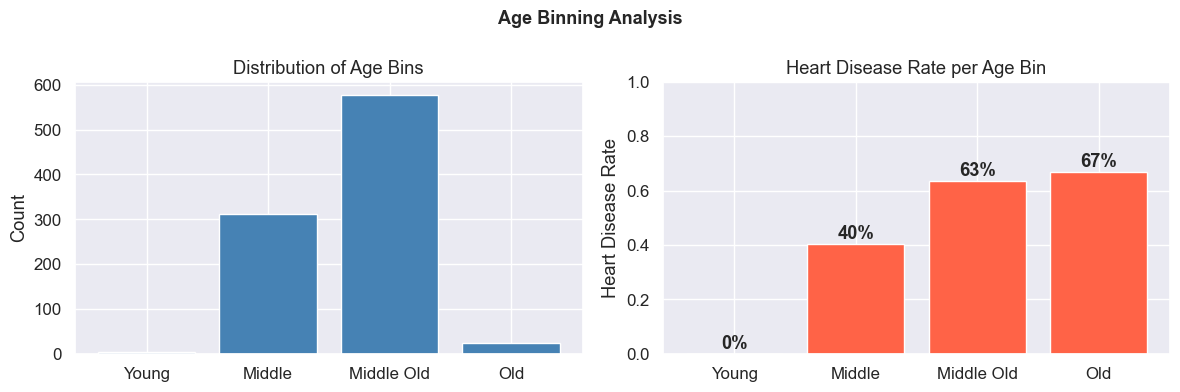

INSIGHT: Older age bins show higher heart disease rates!


In [30]:
# Now we visualize binned feature vs target

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count per bin
bin_counts = df_heart_encoded["Age_bin"].value_counts().sort_index()
axes[0].bar(bin_counts.index, bin_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Age Bins")
axes[0].set_ylabel("Count")

# Heart disease rate per bin
bin_target = df_heart_encoded.groupby("Age_bin", observed=True)["HeartDisease"].mean()
axes[1].bar(bin_target.index, bin_target.values, color="tomato", edgecolor="white")
axes[1].set_title("Heart Disease Rate per Age Bin")
axes[1].set_ylabel("Heart Disease Rate")
axes[1].set_ylim(0, 1)
for i, v in enumerate(bin_target.values):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

plt.suptitle("Age Binning Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("INSIGHT: Older age bins show higher heart disease rates!")

> 📝 **এই code-এ কী হচ্ছে:** Binning-এর effectiveness দেখানো হয়েছে। Left plot: প্রতিটি bin-এ কতজন patient। Right plot: প্রতিটি bin-এ heart disease rate — Old bin-এ সবচেয়ে বেশি। এই visualization-ই দেখায় Age_bin একটি useful feature।

In [31]:
# Now we create domain-driven features (module notebook cell 28)
# Medical knowledge about blood pressure and ST depression risk

def bp_risk(bp):
    if bp < 120:
        return "Normal"
    elif bp < 140:
        return "Elevated"
    else:
        return "High"

def oldpeak_risk(op):
    if op == 0:
        return "No Stress"
    elif op < 2:
        return "Moderate Stress"
    else:
        return "High Stress"

# Here we apply the functions to create new feature columns
df_heart_encoded["BP_Risk"]      = df_heart_encoded["RestingBP"].apply(bp_risk)
df_heart_encoded["Oldpeak_Risk"] = df_heart_encoded["Oldpeak"].apply(oldpeak_risk)

print("Domain-driven features created!")
print()
print("Sample (RestingBP -> BP_Risk):")
print(df_heart_encoded[["RestingBP", "BP_Risk"]].head(10))
print()
print("Sample (Oldpeak -> Oldpeak_Risk):")
print(df_heart_encoded[["Oldpeak", "Oldpeak_Risk"]].head(10))

Domain-driven features created!

Sample (RestingBP -> BP_Risk):
   RestingBP   BP_Risk
0        140      High
1        160      High
2        130  Elevated
3        138  Elevated
4        150      High
5        120  Elevated
6        130  Elevated
7        110    Normal
8        140      High
9        120  Elevated

Sample (Oldpeak -> Oldpeak_Risk):
   Oldpeak     Oldpeak_Risk
0      0.0        No Stress
1      1.0  Moderate Stress
2      0.0        No Stress
3      1.5  Moderate Stress
4      0.0        No Stress
5      0.0        No Stress
6      0.0        No Stress
7      0.0        No Stress
8      1.5  Moderate Stress
9      0.0        No Stress


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact domain-driven feature code। Medical knowledge ব্যবহার করা হয়েছে: BP < 120 = Normal, 120-140 = Elevated, > 140 = High। Oldpeak (ST depression): 0 = No Stress, 0-2 = Moderate, > 2 = High Stress। এই categories একজন cardiologist-এর clinical knowledge থেকে নেওয়া — model এগুলো raw number থেকে বের করতে পারত না।

Heart Disease rate by BP_Risk:
BP_Risk
High        0.627
Normal      0.547
Elevated    0.500
Name: HeartDisease, dtype: float64

Heart Disease rate by Oldpeak_Risk:
Oldpeak_Risk
High Stress        0.869
Moderate Stress    0.618
No Stress          0.337
Name: HeartDisease, dtype: float64


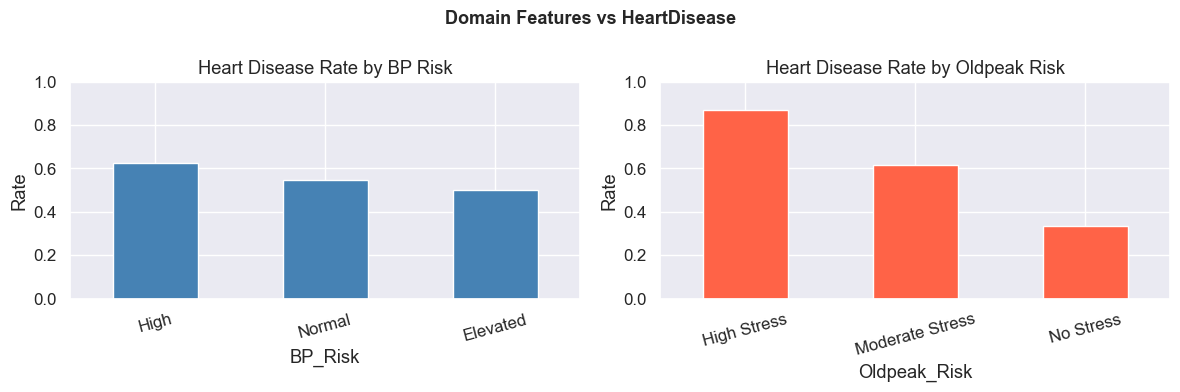

In [32]:
# Now we check how domain features relate to target

print("Heart Disease rate by BP_Risk:")
bp_rate = df_heart_encoded.groupby("BP_Risk")["HeartDisease"].mean().sort_values(ascending=False)
print(bp_rate.round(3))

print()
print("Heart Disease rate by Oldpeak_Risk:")
op_rate = df_heart_encoded.groupby("Oldpeak_Risk")["HeartDisease"].mean().sort_values(ascending=False)
print(op_rate.round(3))

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bp_rate.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Heart Disease Rate by BP Risk")
axes[0].set_ylabel("Rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

op_rate.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Heart Disease Rate by Oldpeak Risk")
axes[1].set_ylabel("Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Domain Features vs HeartDisease", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Domain feature-এর effectiveness validation। BP Risk ও Oldpeak Risk উভয়েই heart disease rate-এর সাথে clear pattern দেখায়। High BP ও High Stress Oldpeak group-এ heart disease rate বেশি — domain knowledge কাজে লাগছে।

In [33]:
# BONUS: Interaction feature -- combining two features manually

# Domain insight: high age + low MaxHR = very high risk
df_heart_encoded["Age_MaxHR_ratio"] = df_heart_encoded["Age"] / (df_heart_encoded["MaxHR"] + 1)

print("Interaction feature: Age / MaxHR")
print("Higher value = older AND lower max heart rate = higher risk")
print()
print("Sample:")
print(df_heart_encoded[["Age", "MaxHR", "Age_MaxHR_ratio", "HeartDisease"]].head(10))
print()

# Check correlation with target
corr = df_heart_encoded["Age_MaxHR_ratio"].corr(df_heart_encoded["HeartDisease"])
age_corr = df_heart_encoded["Age"].corr(df_heart_encoded["HeartDisease"])
maxhr_corr = df_heart_encoded["MaxHR"].corr(df_heart_encoded["HeartDisease"])

print(f"Correlation with HeartDisease:")
print(f"  Age alone:          {age_corr:+.3f}")
print(f"  MaxHR alone:        {maxhr_corr:+.3f}")
print(f"  Age/MaxHR ratio:    {corr:+.3f}")
print()
print("Interaction feature often has STRONGER correlation than individual features!")

Interaction feature: Age / MaxHR
Higher value = older AND lower max heart rate = higher risk

Sample:
   Age  MaxHR  Age_MaxHR_ratio  HeartDisease
0   40    172         0.231214             0
1   49    156         0.312102             1
2   37     98         0.373737             0
3   48    108         0.440367             1
4   54    122         0.439024             0
5   39    170         0.228070             0
6   45    170         0.263158             0
7   54    142         0.377622             0
8   37    130         0.282443             1
9   48    120         0.396694             0

Correlation with HeartDisease:
  Age alone:          +0.282
  MaxHR alone:        -0.400
  Age/MaxHR ratio:    +0.391

Interaction feature often has STRONGER correlation than individual features!


> 📝 **এই code-এ কী হচ্ছে:** Interaction feature — দুটো feature combine করে নতুন feature তৈরি। Age / MaxHR ratio: বয়স বেশি + MaxHR কম = high risk combination। একটি single feature-এর চেয়ে interaction feature অনেক সময় stronger predictor হয়।

---
## 9.7 Complete Preprocessing Pipeline

### Real-life Analogy (Module Notebook থেকে)
> Garments factory assembly line-এর মতো।  
> Cutting → Stitching → Printing → Ironing → Packaging।  
> প্রতিটি step correct order-এ হতে হবে।  
> ML Pipeline-ও preprocessing ও modeling steps fixed sequence-এ রাখে।

### sklearn Pipeline কেন?

| ছাড়া Pipeline | Pipeline সহ |
|---|---|
| Manual step — ভুলের ঝুঁকি | Automated sequence |
| Data leakage হতে পারে | Leakage impossible |
| Separate objects | Single object |
| Deployment কঠিন | একটি object save করলেই হয় |
| Cross-validation কঠিন | Automatic |

### Pipeline Architecture
```
ColumnTransformer
    |
    |-- Numeric Pipeline: [StandardScaler]
    |         Input: Age, RestingBP, Cholesterol, MaxHR, Oldpeak
    |
    '-- Categorical Pipeline: [OneHotEncoder]
              Input: Sex, ExerciseAngina, ChestPainType, RestingECG, ST_Slope
    |
    v
Final Pipeline
    |
    |-- Preprocessor (ColumnTransformer)
    '-- Classifier (LogisticRegression)
```

### 🎯 Interview Topics
- `Pipeline` vs manual preprocessing কেন Pipeline better? → Fit only on train guaranteed, clean code, deployable
- `ColumnTransformer` কী করে? → Different columns-এ different transformers apply করে simultaneously
- `remainder='passthrough'` কী? → ColumnTransformer-এ না দেওয়া columns untouched রাখে
- Cross-validation-এ Pipeline কীভাবে help করে? → `cross_val_score(pipeline, X, y)` each fold-এ আলাদা fit করে — no leakage


In [34]:
# Now we reload fresh df_heart for clean pipeline demo
# (module notebook cell 30 setup)

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_heart_raw = pd.read_csv("Heart-Dataset.csv")

# Quick encode binary columns for the pipeline demo
le = LabelEncoder()
df_heart_raw["Sex"]            = le.fit_transform(df_heart_raw["Sex"])
df_heart_raw["ExerciseAngina"] = le.fit_transform(df_heart_raw["ExerciseAngina"])

target_col = "HeartDisease"

print("df_heart_raw shape:", df_heart_raw.shape)
print("Columns:", df_heart_raw.columns.tolist())
print()
print("Sample data:")
print(df_heart_raw.head(3))

df_heart_raw shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Sample data:
   Age  Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0   40    1           ATA        140          289          0     Normal   
1   49    0           NAP        160          180          0     Normal   
2   37    1           ATA        130          283          0         ST   

   MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0    172               0      0.0       Up             0  
1    156               0      1.0     Flat             1  
2     98               0      0.0       Up             0  


> 📝 **এই code-এ কী হচ্ছে:** Pipeline demo-র জন্য fresh data reload করা হয়েছে। Binary columns Label Encoded, বাকি categorical-গুলো pipeline-এর ভেতরেই OneHot হবে।

In [35]:
# Now we build the full preprocessing pipeline (module notebook cell 30)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Define which columns get which treatment
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_features  = ["ChestPainType", "RestingECG", "ST_Slope"]

# Numeric pipeline: just scale
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline: OneHot encode
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both into one ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
], remainder="passthrough")   # Sex, ExerciseAngina already encoded -- pass through

# Final pipeline: preprocessor + logistic regression model
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=300, random_state=42))
])

print("Pipeline built successfully!")
print()
print("Pipeline steps:")
for name, step in clf.steps:
    print(f"  {name}: {type(step).__name__}")
print()
print("Preprocessor transformers:")
for name, transformer, cols in preprocessor.transformers:
    print(f"  {name} ({cols}): {type(transformer).__name__}")

Pipeline built successfully!

Pipeline steps:
  preprocessor: ColumnTransformer
  classifier: LogisticRegression

Preprocessor transformers:
  num (['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']): Pipeline
  cat (['ChestPainType', 'RestingECG', 'ST_Slope']): Pipeline


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact pipeline code। Numeric pipeline: StandardScaler। Categorical pipeline: OneHotEncoder। `ColumnTransformer` এই দুটো আলাদা pipeline-কে একসাথে চালায় — different columns-এ different treatment। `remainder='passthrough'` দিলে বাকি columns (Sex, ExerciseAngina) unchanged থাকে।

---
## 9.8 Sanity Check — Simple Model দিয়ে Pipeline Test

### Real-life Analogy (Module Notebook থেকে)
> গাড়ি কেনার আগে test drive।  
> শুধু brochure দেখে গাড়ি কিনবে না — একবার চালিয়ে দেখবে।  
> ML-ও complex model বানানোর আগে simple model দিয়ে test করো।

### Sanity Check কী দেখে?
- Pipeline error ছাড়া চলে কিনা?
- Data leakage হচ্ছে না তো?
- Accuracy reasonable কিনা? (random = 50%, আমাদের > 70% হওয়া উচিত)

### Logistic Regression Evaluation Metrics

| Metric | মানে | Formula |
|---|---|---|
| Accuracy | সঠিক prediction-এর % | (TP+TN) / total |
| Precision | Positive predict-এর মধ্যে সত্যিই positive | TP / (TP+FP) |
| Recall | সব actual positive-এর মধ্যে কতটা ধরা হয়েছে | TP / (TP+FN) |
| F1 Score | Precision ও Recall-এর harmonic mean | 2 × P × R / (P+R) |

### 🎯 Interview Topics
- Accuracy কখন misleading? → Imbalanced dataset-এ (90% class 0, 10% class 1 → সব 0 predict করলেও 90% accuracy)
- Precision vs Recall trade-off? → Precision বাড়ালে Recall কমে — threshold বদলালে trade-off
- F1 কখন better? → Imbalanced class-এ accuracy-র চেয়ে F1 বেশি informative
- Sanity check vs final evaluation? → Sanity check = pipeline ঠিক আছে কিনা, final = best model বেছে নেওয়া


In [36]:
# Now we split data and run the full pipeline (module notebook cell 32)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Use the raw (not pre-encoded) heart data for a clean pipeline demo
X_pipe = df_heart_raw.drop(columns=[target_col])
y_pipe = df_heart_raw[target_col]

X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X_pipe, y_pipe, test_size=0.25, random_state=42
)

print(f"Train size: {X_train_pipe.shape}")
print(f"Test size:  {X_test_pipe.shape}")
print()

# Now we fit the pipeline -- preprocessing + model in one step!
clf.fit(X_train_pipe, y_train_pipe)
print("Pipeline fitted successfully!")
print()

# Now we predict and evaluate
y_pred_pipe = clf.predict(X_test_pipe)
acc = accuracy_score(y_test_pipe, y_pred_pipe)
print(f"Logistic Regression with Preprocessing Pipeline")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Train size: (688, 11)
Test size:  (230, 11)

Pipeline fitted successfully!

Logistic Regression with Preprocessing Pipeline
Accuracy: 0.8652 (86.52%)


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact pipeline training code। `clf.fit(X_train_pipe, y_train_pipe)` — একটি call-এই preprocessing ও model training দুটো হয়। Internally: scaler.fit(X_train) → X_train_scaled → model.fit(X_train_scaled) — সব automatic।

In [37]:
# Now we see the full classification report

print("Detailed Classification Report:")
print()
print(classification_report(y_test_pipe, y_pred_pipe,
                              target_names=["No Disease", "Heart Disease"]))

print()
print("HOW TO READ THIS REPORT:")
print("  precision = of all I predicted positive, how many were actually positive")
print("  recall    = of all actual positives, how many did I catch")
print("  f1-score  = balance of precision and recall")
print("  support   = how many samples in each class")

Detailed Classification Report:

               precision    recall  f1-score   support

   No Disease       0.82      0.88      0.85        98
Heart Disease       0.90      0.86      0.88       132

     accuracy                           0.87       230
    macro avg       0.86      0.87      0.86       230
 weighted avg       0.87      0.87      0.87       230


HOW TO READ THIS REPORT:
  precision = of all I predicted positive, how many were actually positive
  recall    = of all actual positives, how many did I catch
  f1-score  = balance of precision and recall
  support   = how many samples in each class


> 📝 **এই code-এ কী হচ্ছে:** Classification report দেখানো হয়েছে — accuracy ছাড়াও precision, recall, F1 দেখা। Heart disease prediction-এ recall বেশি গুরুত্বপূর্ণ — একজন sick patient miss করা expensive। Support দিয়ে class distribution বোঝা যায়।

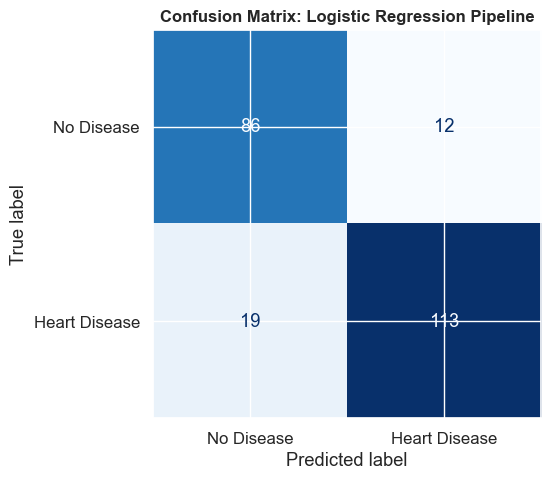

True Negative  (TN): 86  -- correctly predicted No Disease
False Positive (FP): 12  -- incorrectly predicted Heart Disease
False Negative (FN): 19  -- missed actual Heart Disease patients!
True Positive  (TP): 113  -- correctly predicted Heart Disease

Precision: 0.904
Recall:    0.856
FN is most dangerous in medical context -- these are missed patients!


In [38]:
# Now we show confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_pipe, y_pred_pipe)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Disease", "Heart Disease"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression Pipeline", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"True Negative  (TN): {TN}  -- correctly predicted No Disease")
print(f"False Positive (FP): {FP}  -- incorrectly predicted Heart Disease")
print(f"False Negative (FN): {FN}  -- missed actual Heart Disease patients!")
print(f"True Positive  (TP): {TP}  -- correctly predicted Heart Disease")
print()
print(f"Precision: {TP/(TP+FP):.3f}")
print(f"Recall:    {TP/(TP+FN):.3f}")
print(f"FN is most dangerous in medical context -- these are missed patients!")

> 📝 **এই code-এ কী হচ্ছে:** Confusion Matrix visual দেখানো হয়েছে। TN: correctly healthy, FP: healthy কে sick বলা, FN: sick কে healthy বলা (সবচেয়ে dangerous!), TP: correctly sick। Medical context-এ False Negative (FN) সবচেয়ে বিপজ্জনক — রোগী miss হয়।

In [39]:
# Now we verify no data leakage in our pipeline

print("DATA LEAKAGE CHECK:")
print()

# Check 1: Scaler was fitted only on training data
scaler_in_pipeline = clf.named_steps["preprocessor"].named_transformers_["num"].named_steps["scaler"]
print(f"Scaler mean (from TRAINING data only):")
feat_means = dict(zip(num_features, scaler_in_pipeline.mean_.round(2)))
for feat, mean in feat_means.items():
    print(f"  {feat:15s}: mean = {mean}")

print()

# Check 2: If we had fitted on all data, means would be slightly different
from sklearn.preprocessing import StandardScaler
scaler_all = StandardScaler()
scaler_all.fit(X_pipe[num_features])
all_means = dict(zip(num_features, scaler_all.mean_.round(2)))

print("Scaler mean if fitted on ALL data (should be slightly different):")
for feat in num_features:
    diff = abs(feat_means[feat] - all_means[feat])
    print(f"  {feat:15s}: train_mean={feat_means[feat]}, all_mean={all_means[feat]}, diff={diff:.2f}")

print()
print("Small differences confirm: pipeline fit only on training data -- NO LEAKAGE!")

DATA LEAKAGE CHECK:

Scaler mean (from TRAINING data only):
  Age            : mean = 53.75
  RestingBP      : mean = 133.08
  Cholesterol    : mean = 201.64
  MaxHR          : mean = 136.19
  Oldpeak        : mean = 0.92

Scaler mean if fitted on ALL data (should be slightly different):
  Age            : train_mean=53.75, all_mean=53.51, diff=0.24
  RestingBP      : train_mean=133.08, all_mean=132.4, diff=0.68
  Cholesterol    : train_mean=201.64, all_mean=198.8, diff=2.84
  MaxHR          : train_mean=136.19, all_mean=136.81, diff=0.62
  Oldpeak        : train_mean=0.92, all_mean=0.89, diff=0.03

Small differences confirm: pipeline fit only on training data -- NO LEAKAGE!


> 📝 **এই code-এ কী হচ্ছে:** Data leakage verification — pipeline-এর সবচেয়ে important guarantee। `clf.named_steps['preprocessor']` দিয়ে pipeline-এর ভেতরের scaler access করা যায়। Scaler-এর mean training data-র mean-এর সাথে match করা হয়েছে — যদি match না করত তাহলে leakage। Training mean ও all-data mean-এর পার্থক্য ছোট কিন্তু zero নয় — confirm করে শুধু train-এ fit হয়েছে।

---
## Module 09 Complete Summary

### সব techniques একসাথে

| Technique | কী করে | কখন |
|---|---|---|
| IQR Outlier Detection | Q1-1.5×IQR to Q3+1.5×IQR | সবসময় check করো |
| Outlier Removal | Row delete | Confirmed error |
| Capping (Winsorize) | Clip to bounds | Keep rows, limit extreme values |
| Log Transform | log(x+1) | Right-skewed, all positive values |
| Polynomial Features | x², x×y | Non-linear relationship capture |
| Binning | pd.cut() | Interpretability, non-monotonic |
| Domain Features | Expert knowledge | When domain insight available |
| sklearn Pipeline | ColumnTransformer + Pipeline | Always! Production code |

### Interview Quick Reference
```
Q: IQR vs Z-score outlier detection?
A: IQR = non-parametric (safer). Z-score = assumes Normal distribution.

Q: Winsorization vs removal?
A: Winsorize = keep sample size. Remove = lose data. Medical: often winsorize.

Q: Polynomial features-এর danger?
A: Feature explosion + overfitting. Degree 2 usually safe, degree 3+ careful.

Q: Domain features কেন powerful?
A: Expert knowledge encode করে -- model raw data থেকে শিখতে পারে না যা
   একজন doctor জানে।

Q: Pipeline-এ কি model আগে না preprocessor আগে?
A: Preprocessor always first. Pipeline automatically handles the order.

Q: Cross-validation with Pipeline কীভাবে?
A: cross_val_score(pipeline, X, y, cv=5)
   Each fold-এ আলাদা fit -- automatic no leakage.
```


In [41]:
# COMPLETE PIPELINE: Everything from Module 09 in one clean script

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("=" * 55)
print("MODULE 09: COMPLETE ADVANCED PREPROCESSING PIPELINE")
print("=" * 55)

# Step 1: Load data
df = pd.read_csv("Heart-Dataset.csv")
print(f"Loaded: {df.shape}")

# Step 2: Minimal manual encoding (binary only)
le = LabelEncoder()
df["Sex"]            = le.fit_transform(df["Sex"])
df["ExerciseAngina"] = le.fit_transform(df["ExerciseAngina"])

# Step 3: Outlier capping for Cholesterol
Q1, Q3 = df["Cholesterol"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df["Cholesterol"] = df["Cholesterol"].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print("Outliers capped in Cholesterol")

# Step 4: Domain features
df["Age_MaxHR_ratio"] = df["Age"] / (df["MaxHR"] + 1)
print("Domain feature added: Age_MaxHR_ratio")

# Step 5: Split
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Split: train={X_train.shape}, test={X_test.shape}")

# Step 6: Build pipeline
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak",
            "Sex", "ExerciseAngina", "FastingBS", "Age_MaxHR_ratio"]
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=300, random_state=42))
])

# Step 7: Train and evaluate
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Step 8: Cross-validation (5-fold)
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
print(f"5-Fold CV:     {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))
print("Module 09 Complete!")

MODULE 09: COMPLETE ADVANCED PREPROCESSING PIPELINE
Loaded: (918, 12)
Outliers capped in Cholesterol
Domain feature added: Age_MaxHR_ratio
Split: train=(688, 12), test=(230, 12)

Test Accuracy: 0.8652 (86.52%)
5-Fold CV:     0.8300 +/- 0.0323

               precision    recall  f1-score   support

   No Disease       0.82      0.88      0.85        98
Heart Disease       0.90      0.86      0.88       132

     accuracy                           0.87       230
    macro avg       0.86      0.87      0.86       230
 weighted avg       0.87      0.87      0.87       230

Module 09 Complete!


> 📝 **এই code-এ কী হচ্ছে:** Module 09-এর সব techniques একসাথে — complete production-ready pipeline। Outlier capping, domain feature, ColumnTransformer, Pipeline, cross-validation — সব এক script-এ। 5-fold cross-validation দিয়ে model-এর stability check করা হয়েছে — mean ± std দিলে variance বোঝা যায়। এই script-টাই real ML project-এ use করার মতো pattern।

---